# Análisis LTV - (Lifetime value)

**Conociendo la rentabilidad total proyectada de un cliente a lo largo de su relación con la empresa**

Obtendremos un LTV de cada mes de cohorte, en lugar de proyectarlo a toda la vida activa del cliente

Este enfoque calcula el LTV acumulado mes a mes para cada cohorte, mostrando cómo evoluciona su valor en un periodo determinado. Esto permite observar el comportamiento y el valor generado por los clientes a lo largo del tiempo, comparando cohortes entre sí.

**Pasos clave:**

- Agrupación por Cohorte: Partimos de la tabla de cohortes ya calculada

- Cálculo mensual del LTV: Se calcula el LTV mensual para cada cohorte sumando las ventas generadas por los clientes de esa cohorte en cada mes posterior a su ingreso (Mes1, Mes2, Mes3, etc.). Esto permite ver cómo va evolucionando el valor total generado por esa cohorte con el paso de los meses.

- Evaluación del LTV por Cohorte: En lugar de proyectar el LTV total para toda la vida del cliente, se observa el LTV acumulado de cada cohorte en función de su antigüedad, mostrando cómo los ingresos generados por cada cohorte cambian a lo largo del tiempo.

## Importación de librerías y carga de datos

In [2]:
# Importación de librerías
import pandas as pd

ruta_absoluta_prod =  r'C:/Users/armil/Desktop/Begoña/data d4bs/CASOS/CASO FINAL 2/00 Datasets/productos_final.csv'
ruta_absoluta = r'C:/Users/armil/Desktop/Begoña/data d4bs/CASOS/CASO FINAL 2/00 Datasets/clientes_final.csv'

productos = pd.read_csv(ruta_absoluta_prod, parse_dates=['Fecha'])
clientes = pd.read_csv(ruta_absoluta, parse_dates=['Fecha_Nacimiento'])

In [4]:
productos.head()

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32


In [5]:
clientes.head()

,ID_Cliente,Fecha_Nacimiento,Genero,Codigo_Postal,Nivel_Educativo,Ocupacion,Tamano_Hogar,CAC
0,1,1969-11-23,Hombre,46001,Universitario,Empleado,4-5 personas,184.31
1,2,1973-08-07,Hombre,7003,Sin estudios,Empleado,1 persona,31.60
2,3,1967-06-03,Mujer,11001,Bachillerato,Estudiante,4-5 personas,29.33
3,4,1975-10-22,Hombre,38002,Bachillerato,Empleado,2-3 personas,63.67
4,5,1997-07-12,Mujer,28003,Universitario,Estudiante,2-3 personas,11.13


## Partimos de la tabla del análisis de cohortes

Retomamos el código unificado, donde entre otros, tenemos la tabla de resultados_filtrados

In [7]:
# Crear la columna 'MesTransaccion' a partir de 'Fecha' en formato Period (mes y año)
productos['MesTransaccion'] = productos['Fecha'].dt.to_period('M')

# Añadir el mes de cohorte
productos['MesCohorte'] = productos.groupby('ID_Cliente')['MesTransaccion'].transform('min')

# Eliminar registros de cohortes no completas
resultados = productos[productos['MesCohorte'] <= '2023-07']

# Transformar las variables Mes: a datetime
resultados = resultados.copy()
resultados['MesTransaccion'] = pd.to_datetime(resultados['MesTransaccion'].astype(str), format='%Y-%m')
resultados['MesCohorte'] = pd.to_datetime(resultados['MesCohorte'].astype(str), format='%Y-%m')

# Eliminar registros que no entran en el mes de cohorte de estudio
resultados_filtrados = resultados[resultados['MesTransaccion'] <= resultados['MesCohorte'] + pd.DateOffset(months=5)]

# Crear variable mes desde el punto de vista cliente
resultados_filtrados = resultados_filtrados.copy()

# Paso 1: Crear nuevas columnas temporales como Period[M] sin sobrescribir las originales
mes_transaccion_period = resultados_filtrados['MesTransaccion'].dt.to_period('M')
mes_cohorte_period = resultados_filtrados['MesCohorte'].dt.to_period('M')

# Paso 2: Calcular la diferencia en meses entre las columnas temporales
diferencia_meses = mes_transaccion_period - mes_cohorte_period

# Paso 3: Crear la nueva columna 'MesCliente' con la diferencia calculada
resultados_filtrados.loc[:, 'MesCliente'] = 'M' + diferencia_meses.apply(lambda x: str(x.n + 1))

# Obtener tabla de cohortes
# Crear la tabla pivotada de cohortes para el análisis
tabla_cohortes = pd.pivot_table(
    resultados_filtrados,
    index='MesCohorte',
    columns='MesCliente', # Permite ordenar las filas en los meses de cada cohorte
    values='ID_Cliente',
    aggfunc='nunique'  # Contar clientes únicos por cada cohorte y mes
).fillna(0).astype(int)  # Rellenar NaN con 0 y convertir a enteros

# Calcular tabla de retención
tabla_retencion = tabla_cohortes.div(tabla_cohortes['M1'], axis=0) * 100

tabla_retencion = tabla_retencion.round(1)

## Agregar para conocer las ventas de todos los clientes

In [8]:
# Recurrimos a la tabla resultados_filtrados previa a la creacion de cohortes, porque incluye ID_Cliente
resultados_filtrados

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte,MesCliente
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01-01,2023-01-01,M1
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01-01,2023-01-01,M1
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03-01,2023-03-01,M1
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06-01,2023-03-01,M4
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01-01,2023-01-01,M1
...,...,...,...,...,...,...,...,...,...,...,...,...
78255,2494,2023-07-27,36500,FU5,3ZY0H,3.34,3.0,4.96,14.88,2023-07-01,2023-07-01,M1
78257,3527,2023-04-28,20425,FEW,WG7HI,4.11,3.0,5.18,15.54,2023-04-01,2023-04-01,M1
78258,5063,2023-03-13,11915,29A,PO1N6,3.00,10.0,4.96,49.60,2023-03-01,2023-03-01,M1
78259,17354,2023-06-29,32041,01F,RVG1H,1.47,3.0,1.68,5.04,2023-06-01,2023-06-01,M1


In [9]:
resultados_filtrados.ID_Cliente.nunique()

14367

In [11]:
# Agrupar por MesCohorte y MesCliente
tabla_venta_media = resultados_filtrados.groupby(['MesCohorte', 'MesCliente']).agg(
    clientes_distintos=('ID_Cliente', 'nunique'),  # Número total de clientes distintos
    ventas_totales=('Total_Venta', 'sum')           # Suma del Precio_Total
).reset_index()

# Calcular ltv_mes como la división de total_ventas entre clientes_distintos, generas una nueva colomna calculada compra_media_mes
tabla_venta_media['compra_media_mes'] = tabla_venta_media['ventas_totales'] / tabla_venta_media['clientes_distintos']


# Mostrar la tabla agregada
tabla_venta_media

,MesCohorte,MesCliente,clientes_distintos,ventas_totales,compra_media_mes
0,2023-01-01,M1,3114,207036.09,66.485578
1,2023-01-01,M2,1011,75298.98,74.479703
2,2023-01-01,M3,778,49887.86,64.123213
3,2023-01-01,M4,458,26897.47,58.728100
4,2023-01-01,M5,189,10457.10,55.328571
5,2023-01-01,M6,134,7702.01,57.477687
6,2023-02-01,M1,2051,141044.28,68.768542
7,2023-02-01,M2,408,28712.95,70.374877
8,2023-02-01,M3,241,15143.70,62.836929
9,2023-02-01,M4,121,6453.77,53.336942


## Pivotar la tabla

- Buscamos tener una estructura de meses de actividad por cohorte

In [12]:
# Pivotar la tabla
tabla_venta_media_pivotada = tabla_venta_media.pivot(index='MesCohorte', columns='MesCliente', values='compra_media_mes')

# Mostrar la tabla pivotada
tabla_venta_media_pivotada


MesCliente,M1,M2,M3,M4,M5,M6
MesCohorte,,,,,,
2023-01-01,66.485578,74.479703,64.123213,58.728100,55.328571,57.477687
2023-02-01,68.768542,70.374877,62.836929,53.336942,66.710694,47.971887
2023-03-01,57.673574,56.928846,51.428581,53.788506,52.976214,50.825070
2023-04-01,57.015791,55.928437,52.096140,45.611811,49.944136,51.766868
2023-05-01,56.813972,58.130922,57.358632,55.232122,52.937802,59.755069
2023-06-01,60.652765,53.485905,55.658768,50.169245,52.434126,51.331512
2023-07-01,62.303202,57.550680,63.172436,54.925556,58.689026,72.663235


In [13]:
tabla_retencion

MesCliente,M1,M2,M3,M4,M5,M6
MesCohorte,,,,,,
2023-01-01,100.0,32.5,25.0,14.7,6.1,4.3
2023-02-01,100.0,19.9,11.8,5.9,3.5,2.6
2023-03-01,100.0,18.1,14.0,12.1,9.5,9.9
2023-04-01,100.0,19.4,15.8,12.7,14.2,13.5
2023-05-01,100.0,18.6,16.3,13.3,16.0,15.5
2023-06-01,100.0,14.4,13.9,14.5,14.1,14.0
2023-07-01,100.0,12.6,13.4,13.9,13.2,14.6


## Calcular el LTV medio a 6M

Lo calculamos multiplicando la venta media por la tasa de retención.

In [14]:
# Calcular el LTV
tabla_ltv =  tabla_venta_media_pivotada * tabla_retencion / 100
tabla_ltv['ltv'] = tabla_ltv.sum(axis=1)

tabla_ltv

#tabla_ltv.sum(axis=1)

# axis=1 → sumar por filas (horizontal)
# Se usa para obtener el LTV total sumando todos los meses de cada cohorte.


MesCliente,M1,M2,M3,M4,M5,M6,ltv
MesCohorte,,,,,,,
2023-01-01,66.485578,24.205904,16.030803,8.633031,3.375043,2.471541,121.201899
2023-02-01,68.768542,14.004601,7.414758,3.146880,2.334874,1.247269,96.916923
2023-03-01,57.673574,10.304121,7.200001,6.508409,5.032740,5.031682,91.750528
2023-04-01,57.015791,10.850117,8.231190,5.792700,7.092067,6.988527,95.970393
2023-05-01,56.813972,10.812351,9.349457,7.345872,8.470048,9.262036,102.053736
2023-06-01,60.652765,7.701970,7.736569,7.274541,7.393212,7.186412,97.945468
2023-07-01,62.303202,7.251386,8.465106,7.634652,7.746951,10.608832,104.010130


**Lifetime Value medio a 6 meses**

In [10]:
LTV_6_meses = tabla_ltv.ltv.mean()
LTV_6_meses

101.40701114340274

**Observación**

- Ya sabemos la media de facturación que vamos a tener con cada nuevo cliente en los próximos 6 meses.
- Esta media es solo una aproximacion rápida para ver la magnitud del dato, pero que la forma correcta para el dato exacto sería hacerla a nivel cliente y no como media de medias

Proximos pasos:
Podemos calcular cómo va a ir siendo la evolución del cliente medio y compararla con el CAC medio.

## Calcular el CAC medio a 6M

In [15]:
# Calcular CAC medio con un merge utilizando 'ID_Cliente' como clave
resultados_filtrados = resultados_filtrados.merge(
    clientes[['ID_Cliente', 'CAC']],  # Solo selecciona 'ID_Cliente' y 'CAC' de la tabla de clientes
    on='ID_Cliente',                 
    how='left'                       
)

In [16]:
resultados_filtrados.head()

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte,MesCliente,CAC
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01-01,2023-01-01,M1,184.31
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01-01,2023-01-01,M1,184.31
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03-01,2023-03-01,M1,31.60
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06-01,2023-03-01,M4,31.60
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01-01,2023-01-01,M1,29.33


In [17]:
# Lo agregamos a nivel cliente
cac_cliente = resultados_filtrados.groupby('ID_Cliente')['CAC'].first()
cac_medio = cac_cliente.mean()
cac_medio

np.float64(69.44205818890514)

## Evolución del cliente medio

Creamos una función que nos calcule el gasto acumulado a lo largo de los meses para el cliente medio y lo compararemos con el CAC medio

In [18]:
import matplotlib.pyplot as plt

def evolucion_cliente(df, cac):
    # Crear las columnas acumuladas
    df['M1_acum'] = df['M1']
    df['M2_acum'] = df[['M1', 'M2']].sum(axis=1)
    df['M3_acum'] = df[['M1', 'M2', 'M3']].sum(axis=1)
    df['M4_acum'] = df[['M1', 'M2', 'M3', 'M4']].sum(axis=1)
    df['M5_acum'] = df[['M1', 'M2', 'M3', 'M4', 'M5']].sum(axis=1)
    df['M6_acum'] = df[['M1', 'M2', 'M3', 'M4', 'M5', 'M6']].sum(axis=1)

    #Calcular la evolucion media, toma las colum. que ha ido creando en el acumulado, recordando que el rango es cerrado a la izq y abierto a la dcha.
    evolucion_media_cliente = df.iloc[:,7:13].mean()

    #Generar el gráfico   
    evolucion_media_cliente.plot(kind='line', figsize=(8,6), marker='o')
    
    # Añadir título y etiquetas
    plt.xlabel('Mes Cliente')
    plt.ylabel('LTV acumulado medio')
    
    # Ajustar la escala del eje Y
    plt.ylim(0, 150)

    # Añadir una línea horizontal en el valor del CAC
    plt.axhline(y=cac, color='r', linestyle='--', label=f'CAC Medio ({cac})')
    
    # Mostrar el gráfico
    plt.grid(True)
    plt.show()

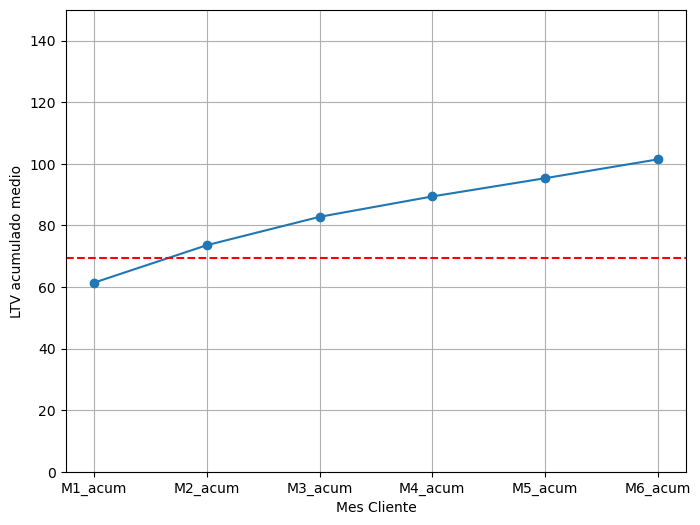

In [19]:
# Llamada a la función
evolucion_cliente(tabla_ltv, cac_medio)

**Observaciónes**

- La gráfica nos permite identificar como de media, en el primer mes de gasto del cliente no se está obteniendo beneficio, debido a que su coste de adquisición es aún máyor.
- A partir del segundo mes ya se convierte en un cliente rentable 'El cliente medio'

En este punto por tanto contamos con información que hemos extraído de los datos, el siguiente paso es el de tomar acciones concretas para mejorar la toma de desciciones

# Plan de Acción 1:  Pre-captación
**Mejorar la rentabilidad en las acciones de captación de clientes**

Nos basaremos en una cohorte reciente para calcular las ventas reales = ltv_real

## Crear una tabla con los clientes de una cohorte reciente

In [20]:
# Seleccionar los clientes que pertenecen a la cohorte 6, clientes activos
clientes_c6 = resultados_filtrados[resultados_filtrados.MesCohorte == '2023-06']
clientes_c6

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte,MesCliente,CAC
20,8,2023-06-21,30687,LPF,IP5IL,2.52,6.0,4.89,29.34,2023-06-01,2023-06-01,M1,70.91
113,42,2023-06-03,27726,X52,GBFC5,5.87,3.0,7.85,23.55,2023-06-01,2023-06-01,M1,75.46
114,42,2023-09-23,45992,3WV,R6HKE,3.16,3.0,5.37,16.11,2023-09-01,2023-06-01,M4,75.46
115,42,2023-09-23,45992,1L6,MGZ43,9.17,3.0,17.13,51.39,2023-09-01,2023-06-01,M4,75.46
132,45,2023-06-06,28118,OXH,VU316,2.11,7.0,3.11,21.77,2023-06-01,2023-06-01,M1,36.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54379,1331,2023-06-30,32363,SIM,K1R89,11.42,3.0,14.70,44.10,2023-06-01,2023-06-01,M1,88.13
54382,4410,2023-06-14,29625,NX3,A9BRM,2.06,7.0,2.73,19.11,2023-06-01,2023-06-01,M1,10.78
54386,17228,2023-06-12,29249,R6E,B4KFE,4.84,5.0,5.62,28.10,2023-06-01,2023-06-01,M1,120.50
54403,17354,2023-06-29,32041,01F,RVG1H,1.47,3.0,1.68,5.04,2023-06-01,2023-06-01,M1,26.46


## Calcular venta total a cada cliente en cada cohorte

In [21]:
# Ventas totales por cliente y cohorte
ltv_real_clientes_c6 = clientes_c6.groupby(['ID_Cliente','MesCliente'])[['Total_Venta']].sum().reset_index()
ltv_real_clientes_c6

,ID_Cliente,MesCliente,Total_Venta
0,8,M1,29.34
1,42,M1,23.55
2,42,M4,67.50
3,45,M1,147.03
4,67,M1,264.66
...,...,...,...
2492,22179,M5,46.30
2493,22206,M1,76.68
2494,22206,M5,124.22
2495,22212,M1,3.96


## Crear una tabla pivotada por cliente y cohorte

Con esto podemos tener el ltv_real al sumar las ventas del cliente en cada cohorte

In [22]:
# Tabla pivotada 
tabla_ltv_real_clientes_c6 = ltv_real_clientes_c6.pivot(index='ID_Cliente', columns='MesCliente', values='Total_Venta').fillna(0)
tabla_ltv_real_clientes_c6

MesCliente,M1,M2,M3,M4,M5,M6
ID_Cliente,,,,,,
8,29.34,0.00,0.0,0.0,0.00,0.0
42,23.55,0.00,0.0,67.5,0.00,0.0
45,147.03,0.00,0.0,0.0,0.00,0.0
67,264.66,0.00,0.0,0.0,0.00,0.0
157,7.29,0.00,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...
22176,24.96,0.00,0.0,0.0,0.00,0.0
22179,35.32,31.76,0.0,0.0,46.30,0.0
22206,76.68,0.00,0.0,0.0,124.22,0.0


In [23]:
# Hacemos la suma de las compras de cada cliente a lo largo de los 6 meses
tabla_ltv_real_clientes_c6['ltv_real'] = tabla_ltv_real_clientes_c6.sum(axis=1)
tabla_ltv_real_clientes_c6

MesCliente,M1,M2,M3,M4,M5,M6,ltv_real
ID_Cliente,,,,,,,
8,29.34,0.00,0.0,0.0,0.00,0.0,29.34
42,23.55,0.00,0.0,67.5,0.00,0.0,91.05
45,147.03,0.00,0.0,0.0,0.00,0.0,147.03
67,264.66,0.00,0.0,0.0,0.00,0.0,264.66
157,7.29,0.00,0.0,0.0,0.00,0.0,7.29
...,...,...,...,...,...,...,...
22176,24.96,0.00,0.0,0.0,0.00,0.0,24.96
22179,35.32,31.76,0.0,0.0,46.30,0.0,113.38
22206,76.68,0.00,0.0,0.0,124.22,0.0,200.90


## Unir los datos sociodemográficos a la tabla

In [24]:
# Obtenemos los sociodemográficos en una variable
sociodemo = clientes[['ID_Cliente','Genero','Nivel_Educativo','Ocupacion','Tamano_Hogar', 'CAC']]

In [25]:
# Hacemos un merge con la tabla clientes para obtener los sociodemográficos
tabla_ltv_real_clientes_c6_completa = tabla_ltv_real_clientes_c6.merge(sociodemo, on = 'ID_Cliente', how = 'left')
tabla_ltv_real_clientes_c6_completa

,ID_Cliente,M1,M2,M3,M4,M5,M6,ltv_real,Genero,Nivel_Educativo,Ocupacion,Tamano_Hogar,CAC
0,8,29.34,0.00,0.0,0.0,0.00,0.0,29.34,Mujer,Bachillerato,Autónomo,4-5 personas,70.91
1,42,23.55,0.00,0.0,67.5,0.00,0.0,91.05,Mujer,Máster,Autónomo,2-3 personas,75.46
2,45,147.03,0.00,0.0,0.0,0.00,0.0,147.03,Hombre,Máster,Desconocido,4-5 personas,36.08
3,67,264.66,0.00,0.0,0.0,0.00,0.0,264.66,Mujer,Universitario,Empleado,2-3 personas,70.00
4,157,7.29,0.00,0.0,0.0,0.00,0.0,7.29,Hombre,Universitario,Desempleado,4-5 personas,50.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,22176,24.96,0.00,0.0,0.0,0.00,0.0,24.96,Mujer,Educación básica,Empleado,4-5 personas,54.88
1457,22179,35.32,31.76,0.0,0.0,46.30,0.0,113.38,Mujer,Desconocido,Desempleado,2-3 personas,31.54
1458,22206,76.68,0.00,0.0,0.0,124.22,0.0,200.90,Mujer,Universitario,Desconocido,2-3 personas,24.46
1459,22212,3.96,0.00,0.0,0.0,0.00,0.0,3.96,Mujer,Sin estudios,Desconocido,2-3 personas,4.27


In [26]:
# Obtenemos el CAC medio para esta cohorte
cac_medio_c6 = tabla_ltv_real_clientes_c6_completa.CAC.mean()
cac_medio_c6

np.float64(71.23369609856262)

## Obtener el punto muerto de cada sociodemográfico con respecto a su CAC medio

In [27]:
# Definimos función de análisis del punto muerto

def analisis_punto_muerto(df,categoria, cac):
    # Crear columnas acumulativas para los meses M1 al M6
    df['M1_acum'] = df['M1']
    df['M2_acum'] = df[['M1', 'M2']].sum(axis=1)
    df['M3_acum'] = df[['M1', 'M2', 'M3']].sum(axis=1)
    df['M4_acum'] = df[['M1', 'M2', 'M3', 'M4']].sum(axis=1)
    df['M5_acum'] = df[['M1', 'M2', 'M3', 'M4', 'M5']].sum(axis=1)
    df['M6_acum'] = df[['M1', 'M2', 'M3', 'M4', 'M5', 'M6']].sum(axis=1)
    
    # Calcular la media de las columnas acumulativas
    acumulativas = ['M1_acum', 'M2_acum', 'M3_acum', 'M4_acum', 'M5_acum', 'M6_acum']
    medias_acumulativas = df[acumulativas].mean()
    
    # Crear el gráfico de líneas de la evolución media
    plt.figure(figsize=(10, 6))
    plt.plot(medias_acumulativas.index, medias_acumulativas.values, marker='o', label='Evolución media')
    
    # Añadir línea horizontal con el valor del CAC
    plt.axhline(y=cac, color='red', linestyle='--', label=f'Valor CAC: {cac}')
    
    # Mostrar la cuadrícula
    plt.grid(True)
    
    # Añadir etiquetas y título
    plt.title(f'Gráfico de la Categoría: {categoria}')
    plt.xlabel('Meses')
    plt.ylabel('Valor Acumulado')
    plt.legend()
    
    # Mostrar el gráfico
    plt.show()
    
    return medias_acumulativas

## Aplicar la función a cada sociodemográfico para identificar puntos de acción

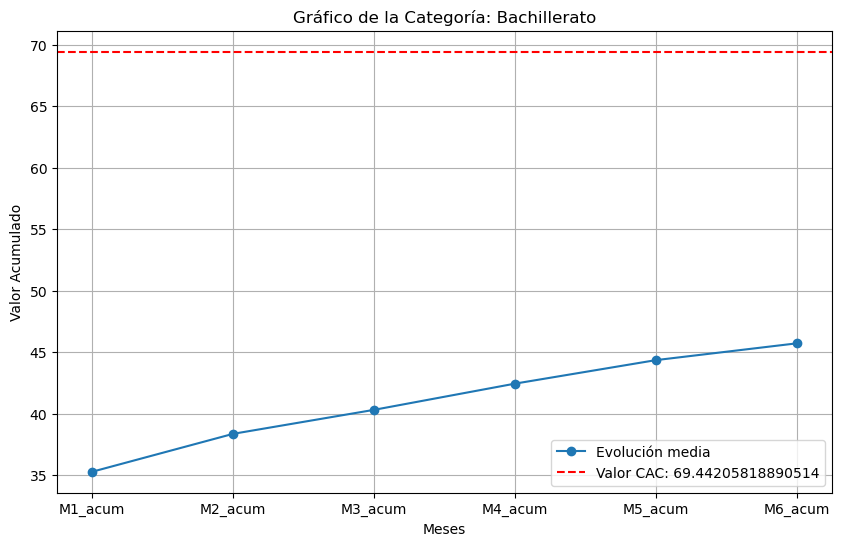

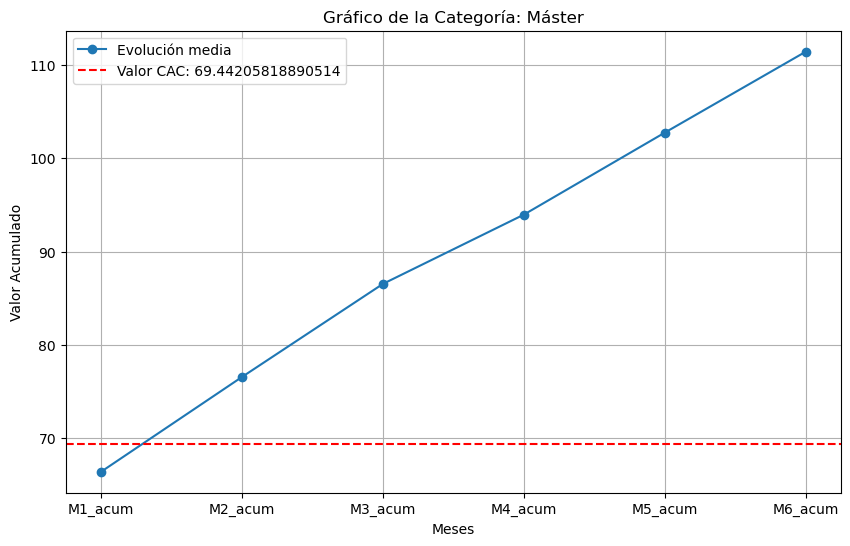

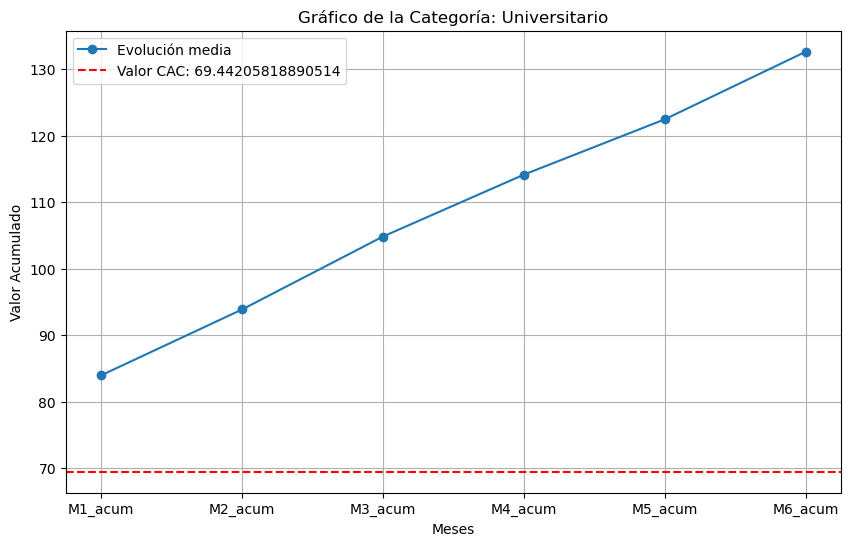

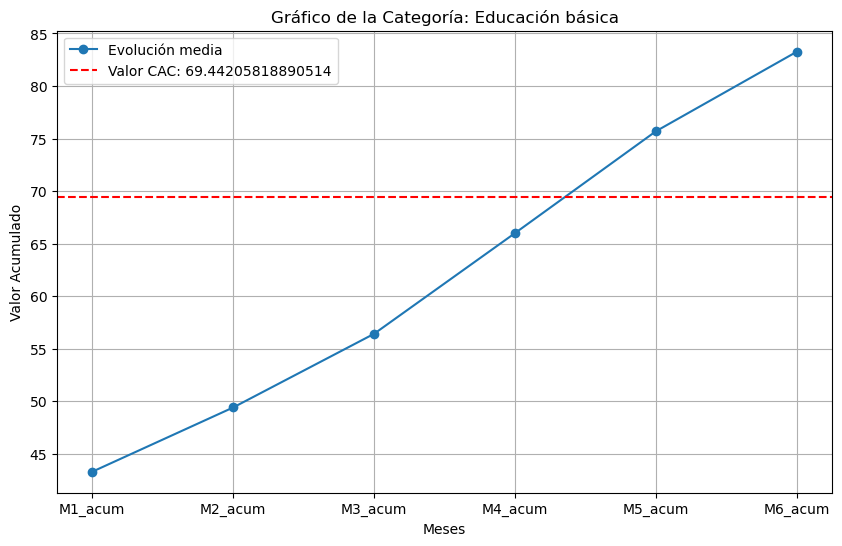

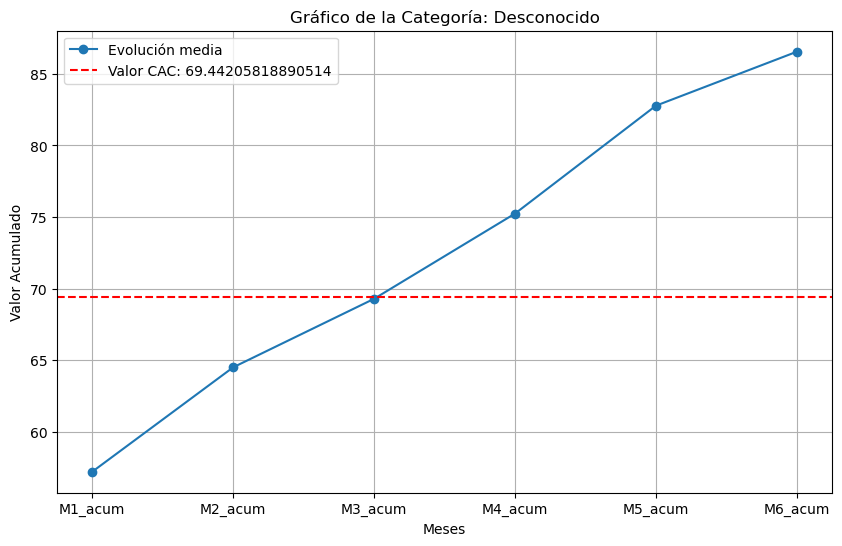

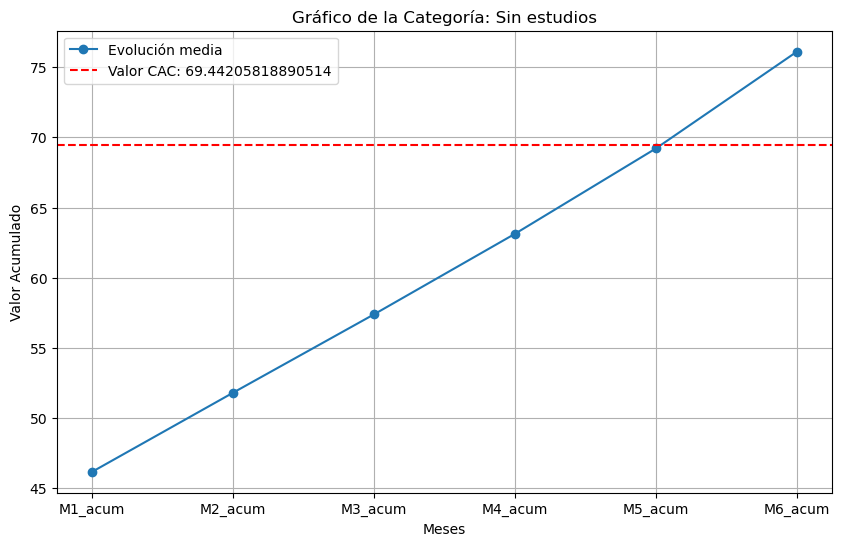

In [28]:
# Aplicamos la función a Nivel Educativo

for cada in tabla_ltv_real_clientes_c6_completa.Nivel_Educativo.unique():
    df_temp = tabla_ltv_real_clientes_c6_completa.loc[tabla_ltv_real_clientes_c6_completa['Nivel_Educativo'] == cada].copy()
    analisis_punto_muerto(df_temp, cada, cac_medio)

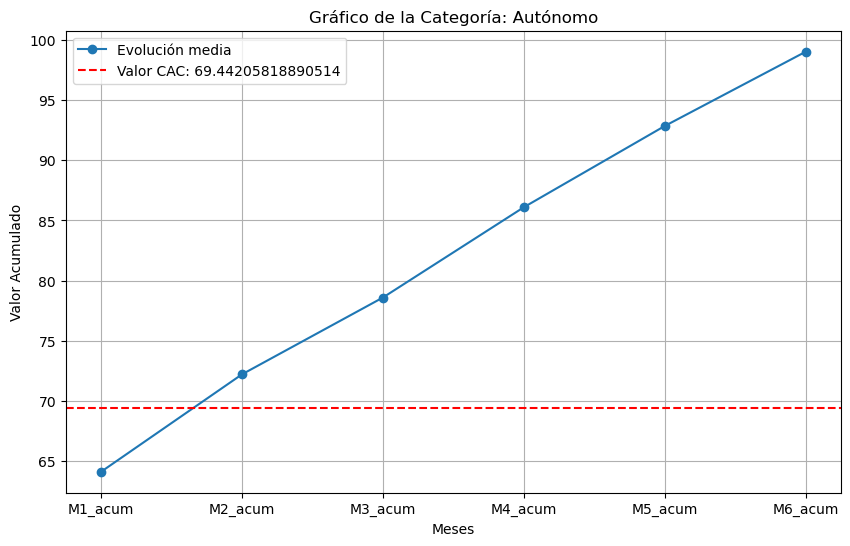

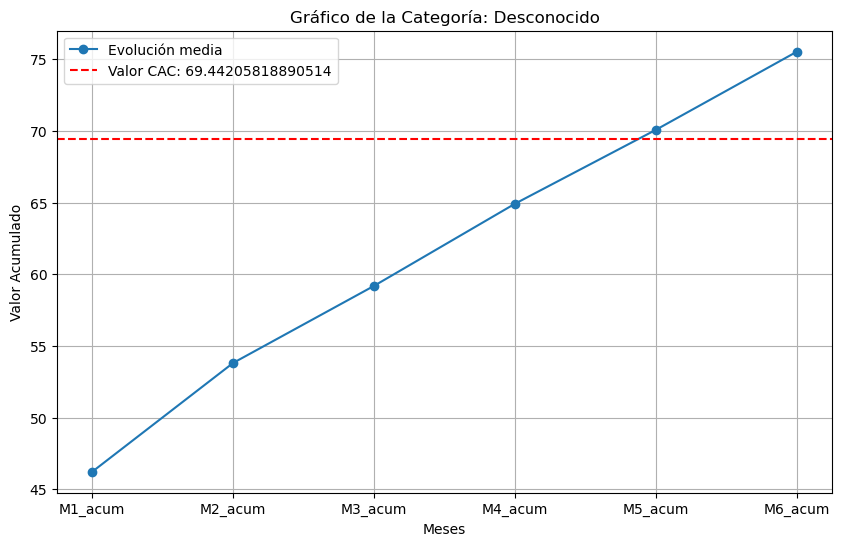

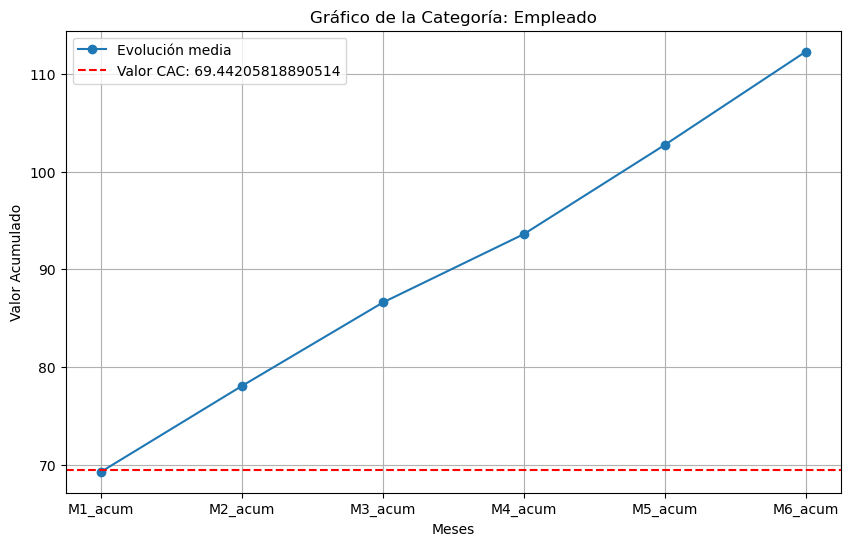

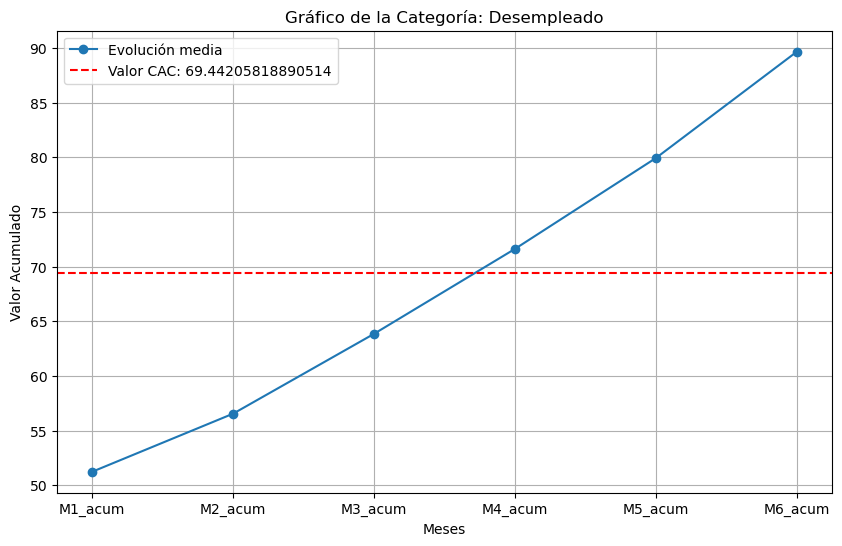

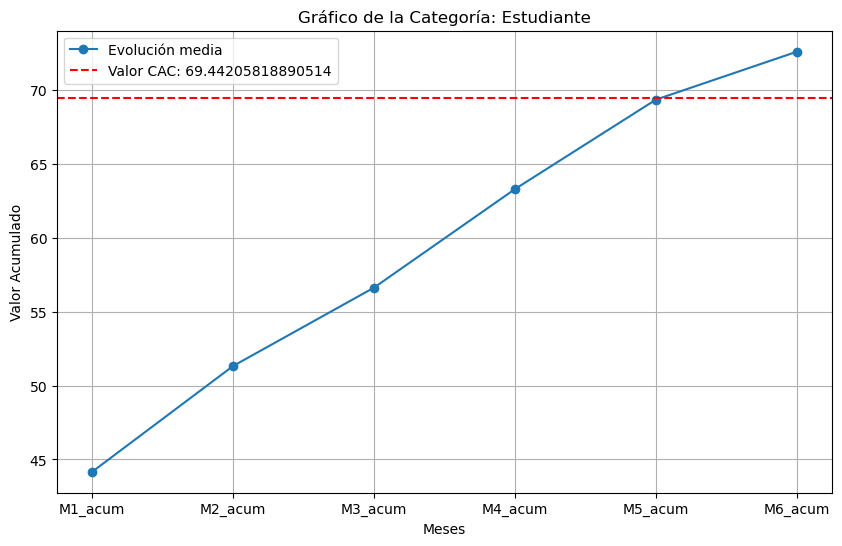

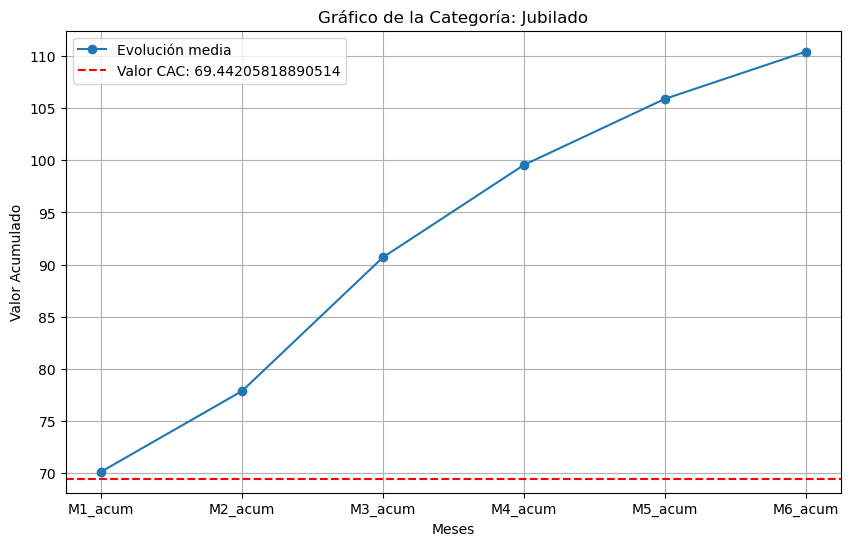

In [29]:
# Aplicamos la función a Ocupación

for cada in tabla_ltv_real_clientes_c6_completa.Ocupacion.unique():
    df_temp = tabla_ltv_real_clientes_c6_completa.loc[tabla_ltv_real_clientes_c6_completa['Ocupacion'] == cada].copy()
    analisis_punto_muerto(df_temp, cada, cac_medio)

**Observaciones**

- Podemos identificar como hay segmentos de clientes con los cuales no estamos generando beneficios en sus 6 meses de vida
- El objetivo ahora es asignar los recursos de CAC de una manera informada, más estratégica, para no perder dinero con algunos segmentos y mejorar ka captación en otros que son más rentables

# Plan de Acción 2: Post-captación

- Trabajaremos con los clientes más recientes, con los que aún no sabemos si nos generarán los resultados esperados
- Crearemos un ltv_predictivo en base a los sociodemográficos, esto lo haremos con el total de los registros para tener una base sólida que nos ayude a estimar mejor

In [30]:
# recuperamos la tabla principal de resultados filtrados
resultados_filtrados

,ID_Cliente,Fecha,ID_Transaccion,Categoria_Producto,Producto,Coste_Unitario,Cantidad,Precio_Unitario,Total_Venta,MesTransaccion,MesCohorte,MesCliente,CAC
0,1,2023-01-21,3442,0H2,6OUVC,7.64,4.0,10.50,42.00,2023-01-01,2023-01-01,M1,184.31
1,1,2023-01-21,3442,N8U,CEBU8,4.57,4.0,5.79,23.16,2023-01-01,2023-01-01,M1,184.31
2,2,2023-03-24,14177,TVL,2SLS0,4.60,3.0,7.77,23.31,2023-03-01,2023-03-01,M1,31.60
3,2,2023-06-19,30451,F9B,GZ6VU,9.04,3.0,15.00,45.00,2023-06-01,2023-03-01,M4,31.60
4,3,2023-01-01,90,LPF,Y1M2E,3.37,4.0,4.08,16.32,2023-01-01,2023-01-01,M1,29.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54400,2494,2023-07-27,36500,FU5,3ZY0H,3.34,3.0,4.96,14.88,2023-07-01,2023-07-01,M1,50.05
54401,3527,2023-04-28,20425,FEW,WG7HI,4.11,3.0,5.18,15.54,2023-04-01,2023-04-01,M1,196.24
54402,5063,2023-03-13,11915,29A,PO1N6,3.00,10.0,4.96,49.60,2023-03-01,2023-03-01,M1,46.72
54403,17354,2023-06-29,32041,01F,RVG1H,1.47,3.0,1.68,5.04,2023-06-01,2023-06-01,M1,26.46


## Calcular la venta total a cada cliente

In [31]:
# Calculo de LTV por cliente
# Agrupamos por cliente y sumamos sus ventas totales
ltv_clientes = resultados_filtrados.groupby('ID_Cliente')[['Total_Venta']].sum()
ltv_clientes.columns = ['ltv']
ltv_clientes

,ltv
ID_Cliente,
1,65.16
2,68.31
3,24.60
4,139.85
5,143.81
...,...
22232,21.00
22233,23.76
22234,221.28


## Incorporar los datos sociodemográficos

In [32]:
# Hacemos un merge con la tabla ya filtrada de sociodemo
ltv_clientes_socio = ltv_clientes.merge(sociodemo, on = 'ID_Cliente', how = 'left')
ltv_clientes_socio

,ID_Cliente,ltv,Genero,Nivel_Educativo,Ocupacion,Tamano_Hogar,CAC
0,1,65.16,Hombre,Universitario,Empleado,4-5 personas,184.31
1,2,68.31,Hombre,Sin estudios,Empleado,1 persona,31.60
2,3,24.60,Mujer,Bachillerato,Estudiante,4-5 personas,29.33
3,4,139.85,Hombre,Bachillerato,Empleado,2-3 personas,63.67
4,5,143.81,Mujer,Universitario,Estudiante,2-3 personas,11.13
...,...,...,...,...,...,...,...
14362,22232,21.00,Hombre,Universitario,Autónomo,2-3 personas,48.37
14363,22233,23.76,Mujer,Universitario,Empleado,2-3 personas,20.30
14364,22234,221.28,Mujer,Máster,Jubilado,2-3 personas,81.66
14365,22235,14.72,Mujer,Bachillerato,Empleado,1 persona,10.36


## Calcular el ltv medio por los sociodemográficos

En este punto escogeremos Nivel_Educativo, Ocupacion y Tamano_Hogar

In [33]:
# Agrupar por ['Nivel_Educativo', 'Ocupacion', 'Tamano_Hogar'] y calcular la media de 'ltv' 
ltv_socio = ltv_clientes_socio.groupby(['Nivel_Educativo', 'Ocupacion', 'Tamano_Hogar']).agg(
    ltv_medio=('ltv', 'mean')    
).reset_index()

ltv_socio

,Nivel_Educativo,Ocupacion,Tamano_Hogar,ltv_medio
0,Bachillerato,Autónomo,1 persona,99.243333
1,Bachillerato,Autónomo,2-3 personas,103.265793
2,Bachillerato,Autónomo,4-5 personas,94.159690
3,Bachillerato,Desconocido,1 persona,74.944286
4,Bachillerato,Desconocido,2-3 personas,84.373093
...,...,...,...,...
103,Universitario,Estudiante,2-3 personas,90.415714
104,Universitario,Estudiante,4-5 personas,78.176750
105,Universitario,Jubilado,1 persona,72.860000
106,Universitario,Jubilado,2-3 personas,102.503525


**Observaciones**

- Esta tabla nos permitirá estimar el ltv futuro de un nuevo cliente en base a sus sociodemográficos

- Para comprobar su eficiencia usaremos los clientes de la cohorte 6 que habíamos preseleccionado anterioremente, nos servirán de test para  para saber que pasaría si usáramos esta estimación en ligar de simplemente la venta media por cliente global

### Venta media por cliente  - valor a mejorar con ltv predictivo


In [34]:
venta_media = resultados_filtrados.groupby('ID_Cliente').Total_Venta.sum().mean()
venta_media

np.float64(102.75640843599919)

## Tabla de clientes de cohorte 6

In [35]:
tabla_ltv_real_clientes_c6_completa

,ID_Cliente,M1,M2,M3,M4,M5,M6,ltv_real,Genero,Nivel_Educativo,Ocupacion,Tamano_Hogar,CAC
0,8,29.34,0.00,0.0,0.0,0.00,0.0,29.34,Mujer,Bachillerato,Autónomo,4-5 personas,70.91
1,42,23.55,0.00,0.0,67.5,0.00,0.0,91.05,Mujer,Máster,Autónomo,2-3 personas,75.46
2,45,147.03,0.00,0.0,0.0,0.00,0.0,147.03,Hombre,Máster,Desconocido,4-5 personas,36.08
3,67,264.66,0.00,0.0,0.0,0.00,0.0,264.66,Mujer,Universitario,Empleado,2-3 personas,70.00
4,157,7.29,0.00,0.0,0.0,0.00,0.0,7.29,Hombre,Universitario,Desempleado,4-5 personas,50.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,22176,24.96,0.00,0.0,0.0,0.00,0.0,24.96,Mujer,Educación básica,Empleado,4-5 personas,54.88
1457,22179,35.32,31.76,0.0,0.0,46.30,0.0,113.38,Mujer,Desconocido,Desempleado,2-3 personas,31.54
1458,22206,76.68,0.00,0.0,0.0,124.22,0.0,200.90,Mujer,Universitario,Desconocido,2-3 personas,24.46
1459,22212,3.96,0.00,0.0,0.0,0.00,0.0,3.96,Mujer,Sin estudios,Desconocido,2-3 personas,4.27


In [36]:
# Simplificamos la tabla

tabla_ltv_real_clientes_c6_simplificada = tabla_ltv_real_clientes_c6_completa[['ID_Cliente','Nivel_Educativo','Ocupacion','Tamano_Hogar','ltv_real','CAC']].copy()
tabla_ltv_real_clientes_c6_simplificada

,ID_Cliente,Nivel_Educativo,Ocupacion,Tamano_Hogar,ltv_real,CAC
0,8,Bachillerato,Autónomo,4-5 personas,29.34,70.91
1,42,Máster,Autónomo,2-3 personas,91.05,75.46
2,45,Máster,Desconocido,4-5 personas,147.03,36.08
3,67,Universitario,Empleado,2-3 personas,264.66,70.00
4,157,Universitario,Desempleado,4-5 personas,7.29,50.05
...,...,...,...,...,...,...
1456,22176,Educación básica,Empleado,4-5 personas,24.96,54.88
1457,22179,Desconocido,Desempleado,2-3 personas,113.38,31.54
1458,22206,Universitario,Desconocido,2-3 personas,200.90,24.46
1459,22212,Sin estudios,Desconocido,2-3 personas,3.96,4.27


## Incorporar el ltv predictivo

In [37]:
tabla_ltv_real_clientes_c6_simplificada2 = tabla_ltv_real_clientes_c6_simplificada.merge(ltv_socio, how = 'left', on = ['Nivel_Educativo','Ocupacion','Tamano_Hogar'])
tabla_ltv_real_clientes_c6_simplificada2 = tabla_ltv_real_clientes_c6_simplificada2.rename(columns={'ltv_medio': 'ltv_predicho'})
tabla_ltv_real_clientes_c6_simplificada2

,ID_Cliente,Nivel_Educativo,Ocupacion,Tamano_Hogar,ltv_real,CAC,ltv_predicho
0,8,Bachillerato,Autónomo,4-5 personas,29.34,70.91,94.159690
1,42,Máster,Autónomo,2-3 personas,91.05,75.46,172.072987
2,45,Máster,Desconocido,4-5 personas,147.03,36.08,65.555714
3,67,Universitario,Empleado,2-3 personas,264.66,70.00,120.900541
4,157,Universitario,Desempleado,4-5 personas,7.29,50.05,84.687342
...,...,...,...,...,...,...,...
1456,22176,Educación básica,Empleado,4-5 personas,24.96,54.88,76.165714
1457,22179,Desconocido,Desempleado,2-3 personas,113.38,31.54,73.948295
1458,22206,Universitario,Desconocido,2-3 personas,200.90,24.46,99.753345
1459,22212,Sin estudios,Desconocido,2-3 personas,3.96,4.27,50.321525


## Cálculo de los errores. real vs predicho

En este punto nos basaremos en los errores medios reales vs los predichos, así podremos identificar si nuestra estrategia es correcta y puede generar beneficios

Formas de calcular los errores:

- Real: restamos el ltv_real con la venta media
- Predicho: restamos el ltv_predicho con la venta media

In [34]:
tabla_ltv_real_clientes_c6_simplificada2['error_real'] = abs(tabla_ltv_real_clientes_c6_simplificada2['ltv_real'] - venta_media)
tabla_ltv_real_clientes_c6_simplificada2['error_predicho'] = abs(tabla_ltv_real_clientes_c6_simplificada2['ltv_predicho'] - venta_media)
tabla_ltv_real_clientes_c6_simplificada2

,ID_Cliente,Nivel_Educativo,Ocupacion,Tamano_Hogar,ltv_real,CAC,ltv_predicho,error_real,error_predicho
0,8,Bachillerato,Autónomo,4-5 personas,29.34,70.91,94.159690,73.416408,8.596719
1,42,Máster,Autónomo,2-3 personas,91.05,75.46,172.072987,11.706408,69.316578
2,45,Máster,Desconocido,4-5 personas,147.03,36.08,65.555714,44.273592,37.200694
3,67,Universitario,Empleado,2-3 personas,264.66,70.00,120.900541,161.903592,18.144132
4,157,Universitario,Desempleado,4-5 personas,7.29,50.05,84.687342,95.466408,18.069067
...,...,...,...,...,...,...,...,...,...
1456,22176,Educación básica,Empleado,4-5 personas,24.96,54.88,76.165714,77.796408,26.590694
1457,22179,Desconocido,Desempleado,2-3 personas,113.38,31.54,73.948295,10.623592,28.808113
1458,22206,Universitario,Desconocido,2-3 personas,200.90,24.46,99.753345,98.143592,3.003063
1459,22212,Sin estudios,Desconocido,2-3 personas,3.96,4.27,50.321525,98.796408,52.434883


In [35]:
# Error medio real
tabla_ltv_real_clientes_c6_simplificada2.error_real.mean()

74.12370934904008

In [36]:
# Error medio predicho
tabla_ltv_real_clientes_c6_simplificada2.error_predicho.mean()

17.951625401200292

**Observaciones**

Claramente podemos comprobar que nuestra estrategia minimiza con diferencia el error, permitiendo crear campañas de fidelización personalizadas

## Código LTV unificado

In [37]:
# # Calcular CAC medio con un merge utilizando 'ID_Cliente' como clave
# resultados_filtrados = resultados_filtrados.merge(
#     clientes[['ID_Cliente', 'CAC']],  # Solo selecciona 'ID_Cliente' y 'CAC' de la tabla de clientes
#     on='ID_Cliente',                 
#     how='left'                       
# )
# # Lo agregamos a nivel cliente
# cac_cliente = resultados_filtrados.groupby('ID_Cliente')['CAC'].first()
# cac_medio = cac_cliente.mean()

# # Calculo de LTV por cliente
# # Agrupamos por cliente y sumamos sus ventas totales
# ltv_clientes = resultados_filtrados.groupby('ID_Cliente')[['Total_Venta']].sum()
# ltv_clientes.columns = ['ltv']